In [1]:
import anndata
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Isocortex-1-IT-ET-Glut"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / "AnnData/" / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 121827 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["subclass"].value_counts()
print(class_counts)

subclass
006 L4/5 IT CTX Glut         44121
007 L2/3 IT CTX Glut         41389
004 L6 IT CTX Glut            9627
005 L5 IT CTX Glut            8558
020 L2/3 IT RSP Glut          7203
022 L5 ET CTX Glut            5927
021 L4 RSP-ACA Glut           1452
001 CLA-EPd-CTX Car3 Glut     1156
002 IT EP-CLA Glut            1112
003 L5/6 IT TPE-ENT Glut      1030
009 L2/3 IT PIR-ENTl Glut       99
010 IT AON-TT-DP Glut           73
008 L2/3 IT ENT Glut            23
025 CA2-FC-IG Glut              18
018 L2 IT PPP-APr Glut          16
019 L2/3 IT PPP Glut            12
016 CA1-ProS Glut                5
017 CA3 Glut                     3
011 L2 IT ENT-po Glut            1
014 LA-BLA-BMA-PA Glut           1
024 L5 PPP Glut                  1
Name: count, dtype: int64


In [5]:
# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
adata = adata[~adata.obs["subclass"].isin(classes_to_remove)] #.copy()

print(f"Classes with less than {n_cells_threshold} cells ({classes_to_remove}) have been removed.")
adata

Classes with less than 100 cells (['009 L2/3 IT PIR-ENTl Glut', '010 IT AON-TT-DP Glut', '008 L2/3 IT ENT Glut', '025 CA2-FC-IG Glut', '018 L2 IT PPP-APr Glut', '019 L2/3 IT PPP Glut', '016 CA1-ProS Glut', '017 CA3 Glut', '011 L2 IT ENT-po Glut', '014 LA-BLA-BMA-PA Glut', '024 L5 PPP Glut']) have been removed.


View of AnnData object with n_obs × n_vars = 121575 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [ ]:
# # Saving filtered AnnData object
# save_path = base_path / f"AnnData/WMB-10Xv3-{select_region}-raw-wmeta-filtered.h5ad"
# sc.write(save_path, adata)

In [6]:
def print_column_info(df):
    for c in df.columns:
        # Explicitly set observed=False to retain current behavior and suppress the warning
        grouped = df[[c]].groupby(c, observed=False).count()
        members = ''
        if len(grouped) < 30:
            members = str(list(grouped.index))
        print(f"Number of unique {c} = {len(grouped)} {members}")

In [7]:
print_column_info(adata.obs)

Number of unique cell_barcode = 119529 
Number of unique barcoded_cell_sample_label = 68 
Number of unique library_label = 68 
Number of unique feature_matrix_label = 1 ['WMB-10Xv3-Isocortex-1']
Number of unique entity = 1 ['cell']
Number of unique brain_section_label = 0 []
Number of unique library_method = 1 ['10Xv3']
Number of unique region_of_interest_acronym = 10 ['ACA', 'AI', 'AUD-TEa-PERI-ECT', 'MO-FRP', 'MOp', 'PL-ILA-ORB', 'RSP', 'SS-GU-VISC', 'VIS', 'VIS-PTLp']
Number of unique donor_label = 36 
Number of unique donor_genotype = 2 ['Ai14(RCL-tdT)/wt', 'Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt']
Number of unique donor_sex = 2 ['F', 'M']
Number of unique dataset_label = 1 ['WMB-10Xv3']
Number of unique x = 121278 
Number of unique y = 121414 
Number of unique cluster_alias = 154 
Number of unique neurotransmitter = 1 ['Glut']
Number of unique class = 1 ['01 IT-ET Glut']
Number of unique subclass = 10 ['001 CLA-EPd-CTX Car3 Glut', '002 IT EP-CLA Glut', '003 L5/6 IT TPE-ENT Glut', '0

In [8]:
# Updated Plot function to include Legends
from matplotlib.lines import Line2D
def plot_umap(xx, yy, cc=None, val=None, label_column=None, fig_width=6, fig_height=6, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.4, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.4, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.4, marker='.')
    
    # Set axis properties
    ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

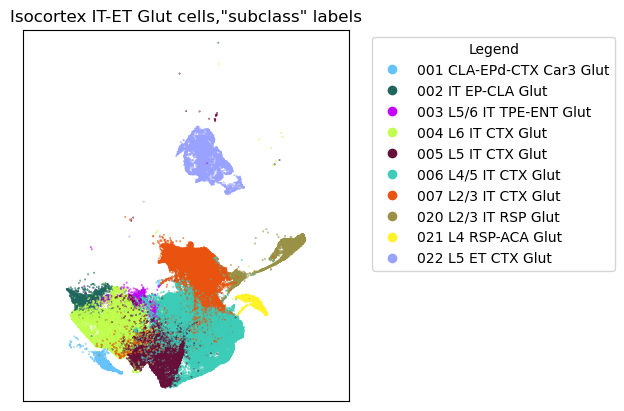

In [9]:
fig, ax = plot_umap(
    adata.obs['x'],
    adata.obs['y'],
    label_column = adata.obs['subclass'],
    cc = adata.obs['subclass_color'],
    fig_width=6,
    fig_height=4
    )
res = ax.set_title("Isocortex IT-ET Glut cells,\"subclass\" labels")
plt.show()

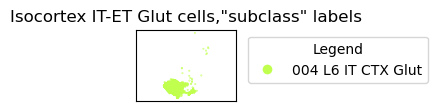

In [17]:
adata_subset = adata[adata.obs['subclass'] == '004 L6 IT CTX Glut']
fig, ax = plot_umap(
    adata_subset.obs['x'],
    adata_subset.obs['y'],
    label_column = adata_subset.obs['subclass'],
    cc = adata_subset.obs['subclass_color'],
    fig_width=3,
    fig_height=1
    )
res = ax.set_title("Isocortex IT-ET Glut cells,\"subclass\" labels")
plt.show()